<a href="https://colab.research.google.com/github/mu20042006-cyber/Machine-Learning-Models/blob/main/Copy_of_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
from datetime import datetime
import joblib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,mean_squared_error

warnings.filterwarnings('ignore')

# ***EDA***

In [ ]:
df=pd.read_csv('final_internship_data.csv')
df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [ ]:
df.shape

(500000, 26)

In [ ]:
df.isnull().sum()


,0
User ID,0
User Name,0
Driver Name,0
Car Condition,0
Weather,0
Traffic Condition,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0


In [ ]:
df_missing= df[df.isnull().any(axis=1)]
df_missing.shape


(5, 26)

In [ ]:
remaining = 5000 - len(df_missing)

df_clean_sample = df[~df.isnull().any(axis=1)].sample(
    n=remaining,
    random_state=42
)


In [ ]:
df = pd.concat([df_missing, df_clean_sample])


In [ ]:
df.shape

(5000, 26)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 120227 to 488641
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User ID            5000 non-null   object 
 1   User Name          5000 non-null   object 
 2   Driver Name        5000 non-null   object 
 3   Car Condition      5000 non-null   object 
 4   Weather            5000 non-null   object 
 5   Traffic Condition  5000 non-null   object 
 6   key                5000 non-null   object 
 7   fare_amount        5000 non-null   float64
 8   pickup_datetime    5000 non-null   object 
 9   pickup_longitude   5000 non-null   float64
 10  pickup_latitude    5000 non-null   float64
 11  dropoff_longitude  4995 non-null   float64
 12  dropoff_latitude   4995 non-null   float64
 13  passenger_count    5000 non-null   int64  
 14  hour               5000 non-null   int64  
 15  day                5000 non-null   int64  
 16  month              500

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fare_amount,5000.0,11.271782,9.517662,-5.000000,6.100000,8.500000,12.500000,120.000000
pickup_longitude,5000.0,-1.265010,0.183308,-1.318551,-1.291410,-1.291228,-1.290966,0.711271
pickup_latitude,5000.0,0.698177,0.138317,-1.291651,0.710953,0.711266,0.711524,7.068002
dropoff_longitude,4995.0,-1.267304,0.245245,-12.786282,-1.291395,-1.291197,-1.290931,0.711458
dropoff_latitude,4995.0,0.697041,0.104532,-1.291345,0.710935,0.711269,0.711535,0.721975
passenger_count,5000.0,1.702400,1.332137,0.000000,1.000000,1.000000,2.000000,6.000000
hour,5000.0,13.537800,6.503586,0.000000,9.000000,14.000000,19.000000,23.000000
day,5000.0,15.697400,8.632377,1.000000,8.000000,16.000000,23.000000,31.000000
month,5000.0,6.270200,3.442726,1.000000,3.000000,6.000000,9.000000,12.000000
weekday,5000.0,3.038000,1.946205,0.000000,1.000000,3.000000,5.000000,6.000000


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols] = df[num_cols].fillna(
    df[num_cols].median()
)


In [ ]:
df['Car Condition'].fillna(
    df['Car Condition'].mode()[0],
    inplace=True
)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 120227 to 488641
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User ID            5000 non-null   object 
 1   User Name          5000 non-null   object 
 2   Driver Name        5000 non-null   object 
 3   Car Condition      5000 non-null   object 
 4   Weather            5000 non-null   object 
 5   Traffic Condition  5000 non-null   object 
 6   key                5000 non-null   object 
 7   fare_amount        5000 non-null   float64
 8   pickup_datetime    5000 non-null   object 
 9   pickup_longitude   5000 non-null   float64
 10  pickup_latitude    5000 non-null   float64
 11  dropoff_longitude  5000 non-null   float64
 12  dropoff_latitude   5000 non-null   float64
 13  passenger_count    5000 non-null   int64  
 14  hour               5000 non-null   int64  
 15  day                5000 non-null   int64  
 16  month              500

In [ ]:
df.isnull().sum()

,0
User ID,0
User Name,0
Driver Name,0
Car Condition,0
Weather,0
Traffic Condition,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0


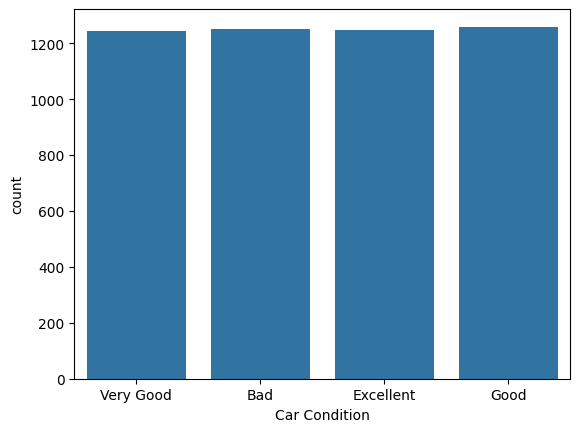

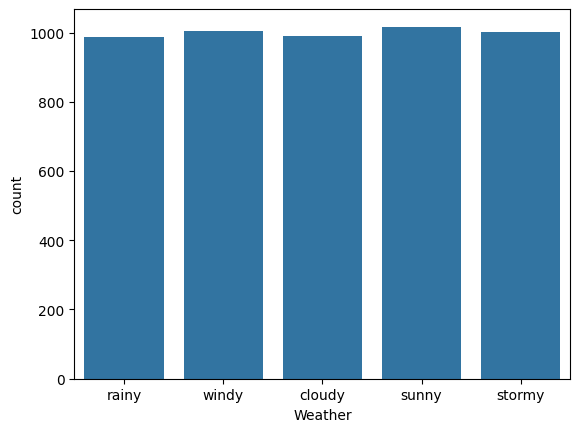

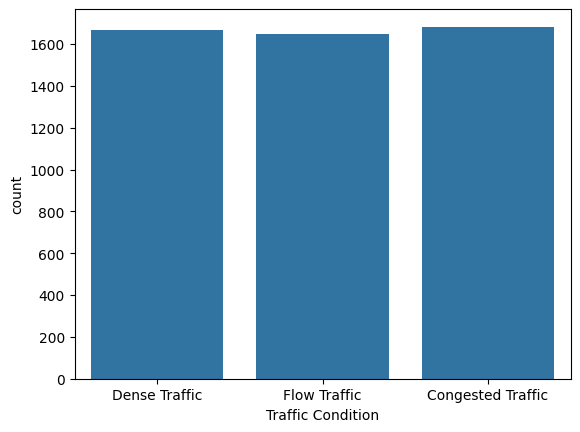

In [ ]:
sns.countplot(x="Car Condition", data=df); plt.show()
sns.countplot(x="Weather", data=df); plt.show()
sns.countplot(x="Traffic Condition", data=df); plt.show()

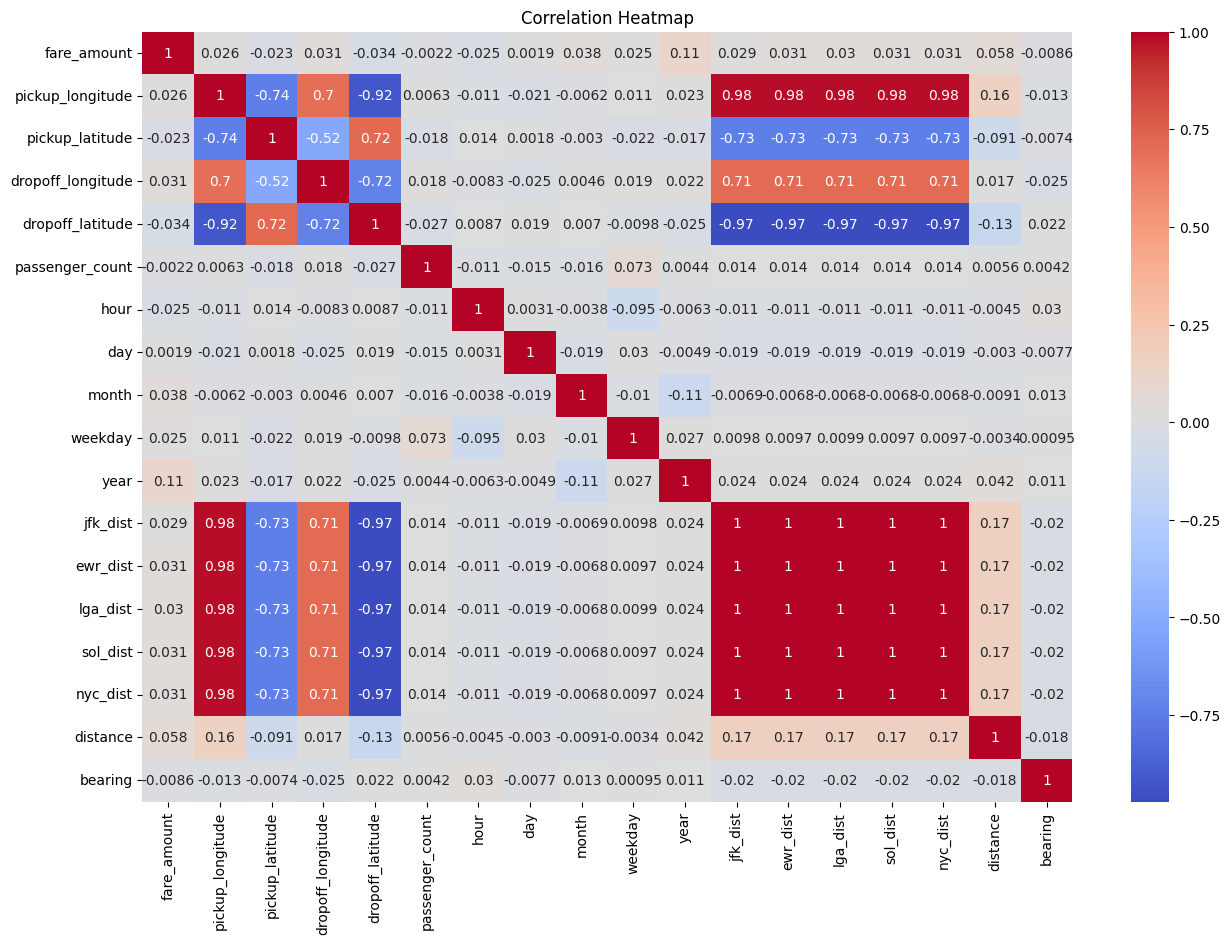

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(columns=['User ID', 'User Name', 'Driver Name','key','pickup_datetime','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude'], inplace=True)


# ***ENCOGING***

In [ ]:
import pandas as pd

# ------------------------
# 1) Ordinal Encoding for Car Condition
# ------------------------
ordinal_map = {
    'Bad': 1,
    'Very Good': 2,
    'Excellent': 3
}

df['Car Condition'] = df['Car Condition'].map(ordinal_map)

# ------------------------
# 2) One-Hot Encoding for Weather + Traffic Condition
# ------------------------

df = pd.get_dummies(
    df,
    columns=['Weather', 'Traffic Condition'],
    drop_first=True
)


In [ ]:
df['Car Condition'] = df['Car Condition'].fillna(
    df['Car Condition'].mode()[0]
)


In [ ]:
dummy_cols = [col for col in df.columns if col.startswith('Weather_') or col.startswith('Traffic Condition_')]

# Convert these dummy columns from boolean (True/False) to integer (1/0)
df[dummy_cols] = df[dummy_cols].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 120227 to 488641
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Car Condition                    5000 non-null   float64
 1   fare_amount                      5000 non-null   float64
 2   passenger_count                  5000 non-null   int64  
 3   hour                             5000 non-null   int64  
 4   day                              5000 non-null   int64  
 5   month                            5000 non-null   int64  
 6   weekday                          5000 non-null   int64  
 7   year                             5000 non-null   int64  
 8   jfk_dist                         5000 non-null   float64
 9   ewr_dist                         5000 non-null   float64
 10  lga_dist                         5000 non-null   float64
 11  sol_dist                         5000 non-null   float64
 12  nyc_dist          

# ***OUTLIRES***

Shape after removing outliers (IQR): (3507, 21)


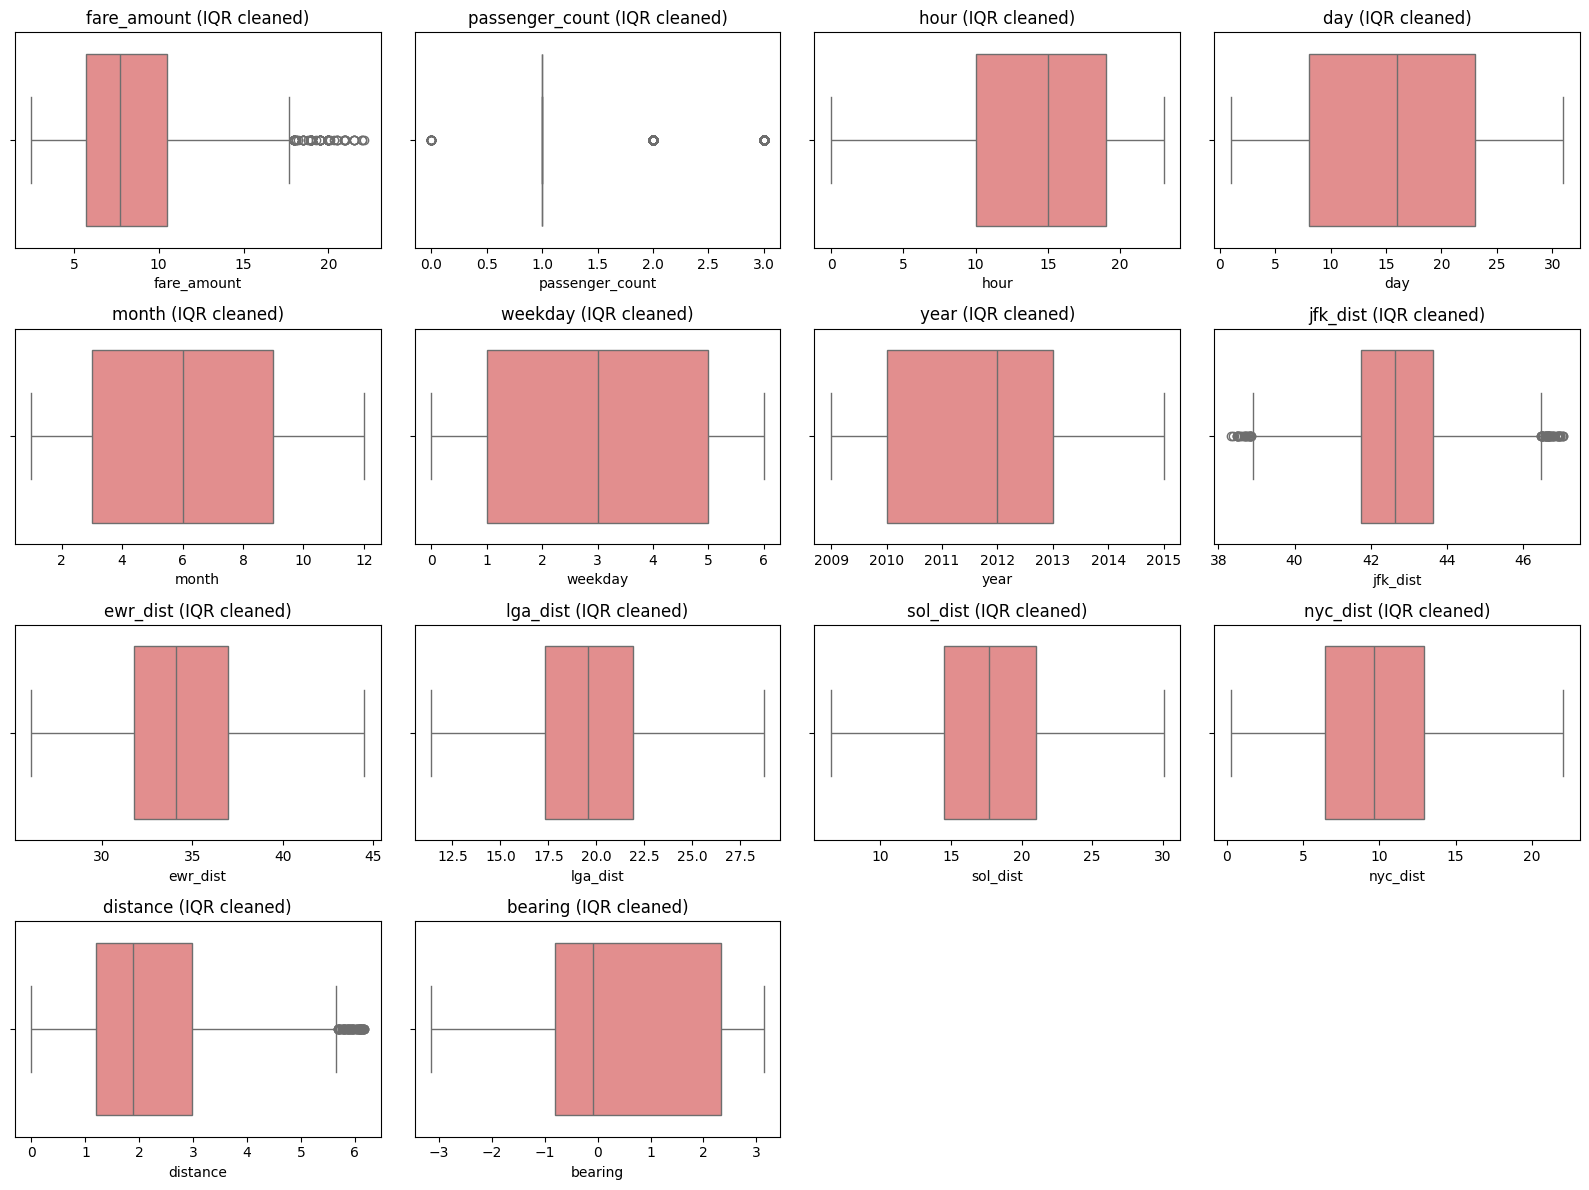

In [ ]:
numeric_cols = ['fare_amount','passenger_count', 'hour', 'day', 'month', 'weekday', 'year',
                'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist',
                'distance', 'bearing']


df_iqr = df.copy()
for col in numeric_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_iqr = df_iqr[(df_iqr[col] >= lower_bound) & (df_iqr[col] <= upper_bound) | (df_iqr[col].isna())]
print("Shape after removing outliers (IQR):", df_iqr.shape)

# Calculate optimal grid size for subplots
num_plots = len(numeric_cols)
num_cols_per_row = 4 # You can adjust this number
num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row # Ceiling division

plt.figure(figsize=(num_cols_per_row * 4, num_rows * 3)) # Adjust figure size dynamically
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(num_rows, num_cols_per_row, i)
    sns.boxplot(x=df_iqr[col], color="lightcoral")
    plt.title(f'{col} (IQR cleaned)')
plt.tight_layout(); plt.show()

In [ ]:

numeric_cols = [
    'fare_amount', 'passenger_count', 'hour', 'day', 'month',
    'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist',
    'sol_dist', 'nyc_dist', 'distance', 'bearing'
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_bound, upper_bound)

print("Shape after capping outliers:", df.shape)
df[numeric_cols].describe()



Shape after capping outliers: (5000, 22)


,fare_amount,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,10.044802,1.525700,13.537800,15.697400,6.270200,3.038000,2011.745800,42.487732,35.625561,19.822367,19.035026,11.237954,2.838475,0.274334
std,5.323697,0.894846,6.503586,8.632377,3.442726,1.946205,1.853718,2.300342,4.844922,4.111572,5.808685,5.671148,2.190217,1.814596
min,-3.500000,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,37.831518,22.943849,9.439125,3.503974,0.285602,0.000000,-3.140881
25%,6.100000,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.386111,32.091650,17.151444,14.808706,7.024304,1.229380,-0.874921
50%,8.500000,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.536458,34.713278,19.658142,18.273615,10.394263,2.123075,-0.080273
75%,12.500000,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.755840,38.190184,22.292990,22.402711,14.363104,3.860311,2.223279
max,22.100000,3.500000,23.000000,31.000000,12.000000,6.000000,2015.000000,47.310433,47.337984,30.005309,33.793718,25.371304,7.806708,3.141593


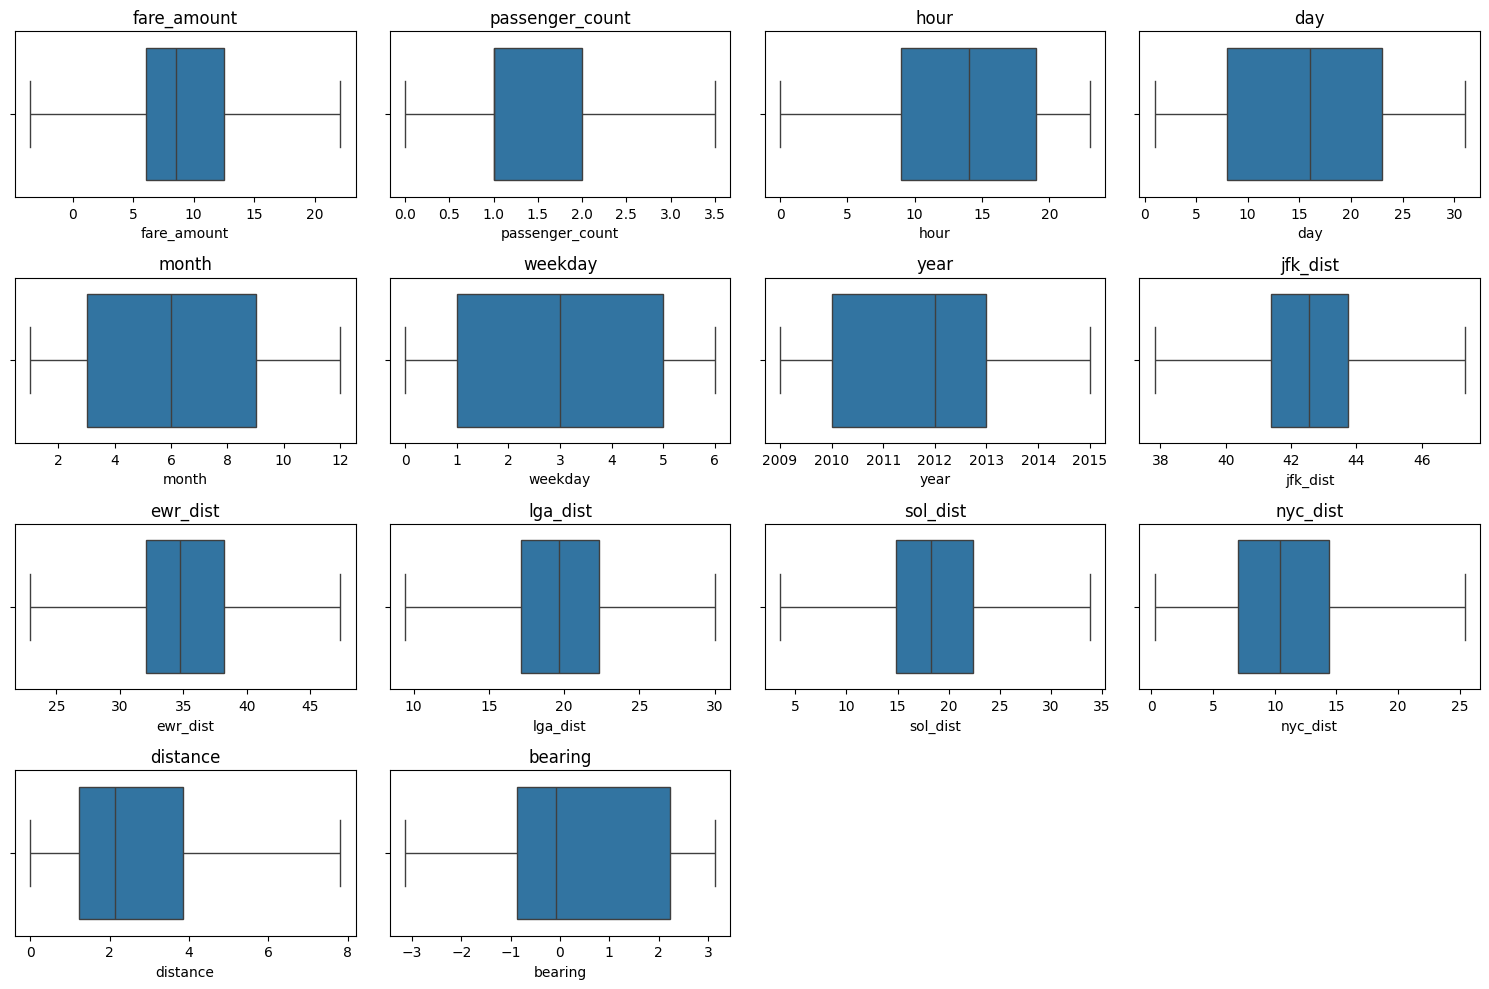

In [ ]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [ ]:
df.head()

,Car Condition,fare_amount,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,...,nyc_dist,distance,bearing,Weather_rainy,Weather_stormy,Weather_sunny,Weather_windy,Traffic Condition_Dense Traffic,Traffic Condition_Flow Traffic,fare_log
120227,2.0,12.5,0.0,12,11,12,1,2012,42.536458,34.713278,...,10.394263,2.123075,-0.080273,1,0,0,0,1,0,2.602690
245696,1.0,22.1,0.0,18,21,3,3,2013,42.536458,34.713278,...,10.394263,2.123075,-0.080273,0,0,0,1,1,0,4.471639
340533,3.0,22.1,0.0,12,11,12,1,2012,42.536458,34.713278,...,10.394263,2.123075,-0.080273,0,0,0,0,1,0,3.349904
428108,2.0,11.8,0.0,9,8,9,3,2011,42.536458,34.713278,...,10.394263,2.123075,-0.080273,0,0,0,0,0,1,2.549445
471472,1.0,7.8,0.0,12,11,12,1,2012,42.536458,34.713278,...,10.394263,2.123075,-0.080273,0,0,0,1,0,0,2.174752


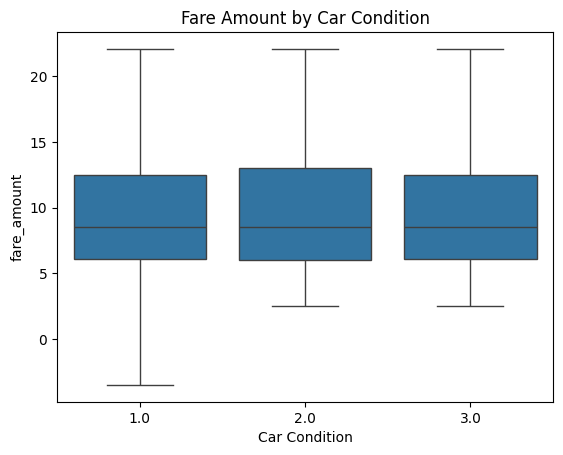

In [ ]:
sns.boxplot(x="Car Condition", y="fare_amount", data=df)
plt.title("Fare Amount by Car Condition")
plt.show()

In [ ]:
from scipy.stats import skew

skewness = skew(df['fare_amount'])
print("Skewness:", skewness)


Skewness: 1.0190560137257596


***TRANSFORM***

In [ ]:







from scipy.stats import skew
import numpy as np

df = df[df['fare_amount'] >= 0]
df['fare_log'] = np.log1p(df['fare_amount'])

skew(df['fare_log'].dropna())


np.float64(0.29622713478416396)

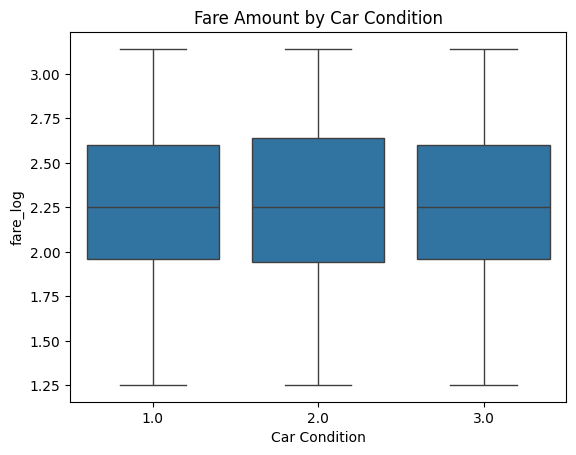

In [ ]:
sns.boxplot(x="Car Condition", y="fare_log", data=df)
plt.title("Fare Amount by Car Condition")
plt.show()

In [ ]:
print("Before log:", skew(df['fare_amount']))
print("After log:", skew(df['fare_log']))


Before log: 1.0227099775093318
After log: 0.29622713478416396


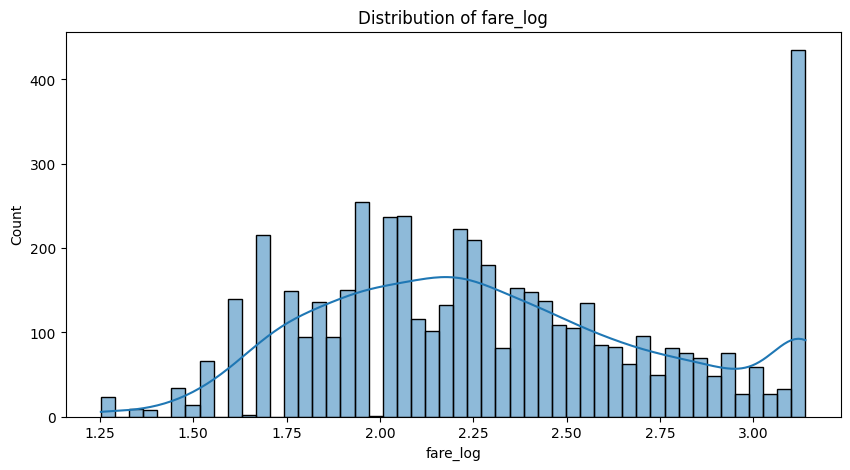

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['fare_log'], bins=50, kde=True)
plt.title("Distribution of fare_log")
plt.show()


# *MODELING & STANDARD*

In [ ]:
X = df.drop(columns=['fare_amount', 'fare_log'])
y = df['fare_log']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_log = model.predict(X_test_scaled)

In [ ]:
import numpy as np
y_pred_amount = np.exp(y_pred_log)
y_test_amount = np.exp(y_test)

In [ ]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.19
Root Mean Squared Error (RMSE): 0.28
R² Score: 0.6212


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


In [ ]:
X = df.drop(columns=['fare_amount', 'fare_log'])
y = df['fare_log']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
model.fit(X_train_scaled, y_train)

ElasticNet(alpha=0.1, random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.21
Root Mean Squared Error (RMSE): 0.29
R² Score: 0.5838
